# Decision Trees

A decision tree classifies (or predicts) by asking a series of **yes/no questions** about the features - literally a flowchart of splits. Follow the answers down from the root and the leaf you land in gives the prediction.

Because the model *is* the flowchart, it is one of the few algorithms you can read like a set of `if/else` rules. It also captures **non-linear** patterns and feature interactions that a straight line (linear/logistic regression) cannot.

**Topics covered in this notebook**

1. Intuition - recursive yes/no splits and how impurity guides them
2. Training on a dataset (iris)
3. Reading the tree & feature importance
4. When to use it

## 1. Intuition

At each node the tree scans every feature and every candidate threshold and picks the single split (e.g. `petal length <= 2.45?`) that best **separates the classes**. It then repeats the same greedy question on each side - this recursion is what makes it a *tree*. Splitting stops when a leaf is **pure** (one class only) or a stopping rule such as `max_depth` kicks in.

### What does "best separates" mean? Impurity.

A node is **pure** if all its samples share one class, and **impure** if the classes are mixed. Scikit-learn's default measures impurity with the **Gini index**. For a node whose samples fall into classes with proportions $p_k$:

$$G = 1 - \sum_{k=1}^{K} p_k^{\,2}$$

$G = 0$ means perfectly pure (one class), and $G$ grows as the mix gets more even. An alternative is **entropy**:

$$H = -\sum_{k=1}^{K} p_k \log_2 p_k$$

### Choosing a split: information gain

For a proposed split that sends fractions of the parent's samples into a left and right child, the tree computes the **weighted** impurity of the children and keeps the split that reduces impurity the most. That reduction is the **information gain**:

$$IG = I(\text{parent}) - \left( \frac{n_{\text{left}}}{n}\, I(\text{left}) + \frac{n_{\text{right}}}{n}\, I(\text{right}) \right)$$

where $I$ is Gini or entropy. The tree is **greedy**: it takes the highest-gain split available at each node, never looking back.

### Overfitting and depth

Left unchecked, a tree keeps splitting until every leaf is pure - which usually means it has **memorized the training noise** and generalizes poorly. Limiting `max_depth` (or `min_samples_leaf`, etc.) stops that. Below we use `max_depth=3` to keep the tree both accurate and readable.

## 2. Training on a Dataset

We classify **iris** flowers into three species (setosa, versicolor, virginica) from four measurements: sepal length/width and petal length/width. `max_depth=3` keeps the tree small and readable while still being accurate.

Note a nice property of trees: **no feature scaling is needed**. Each split compares one feature to a threshold, so the units/ranges of the features don't matter.

In [1]:
from sklearn.datasets import load_iris            # built-in toy dataset (no download)
from sklearn.model_selection import train_test_split  # hold out a test set
from sklearn.tree import DecisionTreeClassifier   # the model we are demonstrating
from sklearn.metrics import accuracy_score        # fraction of correct predictions

In [2]:
# Load the dataset as a Bunch object. It exposes:
#   iris.data          -> feature matrix, shape (150, 4)
#   iris.target        -> integer labels 0/1/2 (the three species)
#   iris.feature_names -> the 4 column names
iris = load_iris()

In [3]:
import pandas as pd  # used only to preview the raw features as a table

# Wrap the numeric feature matrix in a DataFrame purely for readable inspection below.
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

In [4]:
# Peek at the first 5 rows to see the four measurements (all in centimetres).
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
# Summary statistics (count, mean, std, min, quartiles, max) per feature.
# Notice petal length/width vary a lot between species - a hint they'll be strong splitters.
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# Pull out the raw NumPy arrays the model will train on.
# X = features (150, 4), y = target labels (150,) with values in {0, 1, 2}.
X, y = iris.data, iris.target

In [7]:
# Split 80% train / 20% test. We evaluate on data the tree never saw during fitting,
# which is the only honest way to detect overfitting.
# random_state fixes the shuffle so the split (and every result below) is reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

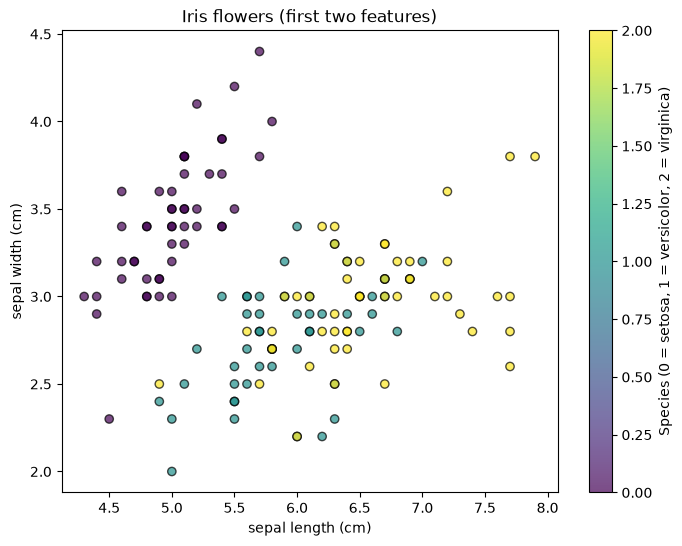

In [8]:
import matplotlib.pyplot as plt

# Quick look at the data using just the first two features (sepal length vs width),
# coloured by species, to get a feel for how separable the classes are.
fig, ax = plt.subplots(figsize=(8, 6))            # own figure/axes for this cell
scatter = ax.scatter(
    X[:, 0], X[:, 1],                             # x = sepal length, y = sepal width
    c=y, cmap='viridis', edgecolor='k', alpha=0.7  # colour each point by its species label
)
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_title('Iris flowers (first two features)')
# Colour bar decodes the 0/1/2 labels back into species names.
fig.colorbar(scatter, ax=ax, label='Species (0 = setosa, 1 = versicolor, 2 = virginica)')
plt.show()

In [9]:
# Create the classifier. max_depth=3 caps the tree at 3 levels of questions so it stays
# readable and does not overfit; random_state makes the (tie-breaking) fit deterministic.
# By default criterion='gini', i.e. splits are chosen to minimise Gini impurity.
tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# fit() runs the greedy recursive-splitting algorithm on the training data.
tree.fit(X_train, y_train)

# predict() drops each test flower down the learned flowchart to its leaf's class.
preds = tree.predict(X_test)

# Accuracy = fraction of test flowers classified correctly.
print("accuracy:", round(accuracy_score(y_test, preds), 3))

accuracy: 1.0


## 3. Reading the Tree & Feature Importance

The biggest selling point of a tree is **interpretability**: you can print the exact rules it learned and see which features it leaned on.

### How to read the printed rules

`export_text` prints the flowchart as indented text. Each line is one node:

- A line like `petal length (cm) <= 2.45` is a **decision node**. The block indented directly under it is the **True** branch (condition holds); the matching `petal length (cm) > 2.45` line is the **False** branch.
- A line like `class: 0` is a **leaf** - the prediction returned for any sample that reaches it.
- To classify a flower, start at the top and follow True/False down the indentation until you hit a `class:` leaf.

### How to read `feature_importances_`

Each split reduces impurity by some amount (its information gain). Scikit-learn sums that reduction per feature, weighted by how many samples pass through the split, then **normalizes so the importances add up to 1.0**. A high value means the feature drove many high-value splits; `0.0` means the tree never split on it at all.

In [10]:
from sklearn.tree import export_text

# Render the learned decision rules as plain, indented text.
# feature_names swaps the internal indices (X[2] etc.) for human-readable column names.
print(export_text(tree, feature_names=list(iris.feature_names)))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



In [11]:
# feature_importances_ is a length-4 array (one weight per feature) that sums to 1.0.
# Print each feature next to its importance so we can see which ones the tree relied on.
print("Feature importance:")
for name, imp in zip(iris.feature_names, tree.feature_importances_):
    # {name:20s} left-pads the name to 20 chars so the numbers line up in a column.
    print(f"  {name:20s} {imp:.4f}")

Feature importance:
  sepal length (cm)    0.0000
  sepal width (cm)     0.0000
  petal length (cm)    0.9346
  petal width (cm)     0.0654


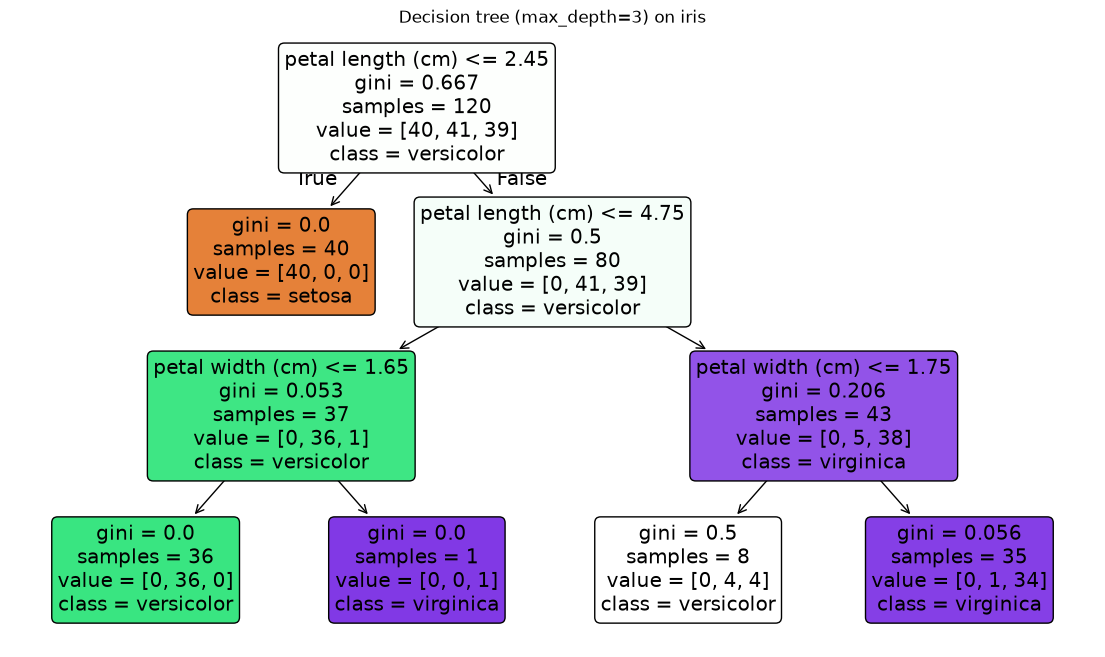

In [12]:
from sklearn.tree import plot_tree

# The same flowchart, drawn visually. Each box shows the split rule, the node's Gini
# impurity, how many samples reached it, the class counts, and its majority class.
fig, ax = plt.subplots(figsize=(14, 8))           # own figure/axes for this plot
plot_tree(
    tree,
    feature_names=iris.feature_names,             # label the split conditions
    class_names=list(iris.target_names),          # label the leaves with species names
    filled=True,                                  # colour boxes by majority class (darker = purer)
    rounded=True,
    ax=ax,
)
ax.set_title('Decision tree (max_depth=3) on iris')
plt.show()

### Evaluating the predictions

Accuracy alone can hide *which* classes a model confuses. A **confusion matrix** shows, for every true species (rows), how the predictions were distributed across species (columns); a perfect model is diagonal. The **classification report** turns those counts into per-class precision, recall and F1.

In [13]:
from sklearn.metrics import confusion_matrix

# Rows = true species, columns = predicted species. Off-diagonal entries are mistakes;
# an all-diagonal matrix (like here) means every test flower was classified correctly.
c_matrix = confusion_matrix(y_test, preds)
print(c_matrix)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [14]:
from sklearn.metrics import classification_report

# Per-class precision (of the flowers predicted class k, how many were right),
# recall (of the actual class-k flowers, how many we caught), and their harmonic
# mean F1 - plus overall/averaged accuracy. target_names labels the rows by species.
c_report = classification_report(y_test, preds, target_names=iris.target_names)
print(c_report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 4. When to Use It

- You need an **interpretable** model you can explain to non-experts as a set of rules.
- The data has **non-linear** relationships or feature interactions a linear model would miss.
- **No feature scaling required** - splits are threshold comparisons, so units don't matter.
- Handles multi-class problems (like the 3 iris species) directly.

**Downside:** a single deep tree **overfits** easily - it can keep splitting until it memorizes noise. Control this with `max_depth` / `min_samples_leaf`, or average many trees together. Averaging is exactly what a **random forest** does, and it's the next notebook.